# Notebook 1 — Data Preparation & Exploratory Analysis

**Project:** Spatiotemporal Soil Dynamics — Southern Africa (1941–2001)  
**Variables:** Clay content (%), pH, Organic Carbon (%)  
**Scope:** Load, clean, and harmonise three raw soil datasets into a single analysis-ready long-format file. Produce exploratory visualisations of spatial coverage, depth structure, and value distributions.

> **Outputs saved by this notebook:**  
> `soil_long.csv` · `clay_ready.csv` · `ph_ready.csv` · `orgc_ready.csv`  
> These are the inputs for Notebooks 2 and 3.

In [1]:
# ── 1.1  Imports & style ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette (project-wide) ────────────────────────────────────────────
PALETTE = {
    "acid":     "#8B0000",
    "neutral":  "#2E7D32",
    "alkaline": "#1E88E5",
    "sand":     "#F5E6C4",
    "charcoal": "#2B2B2B"
}
color_map = {
    "Acidic":   "#8B0000",
    "Neutral":  "#2E7D32",
    "Alkaline": "#1E88E5"
}
VAR_COLORS = {
    "clay": "#A0522D",
    "ph":   "#1E88E5",
    "orgc": "#2E7D32"
}
VAR_CMAPS = {
    "clay": "YlOrBr",
    "ph":   "RdYlBu",
    "orgc": "YlGn"
}
VAR_LABELS = {
    "clay": "Clay (%)",
    "ph":   "pH",
    "orgc": "Organic Carbon (%)"
}
COUNTRY_COLORS = {
    "South Africa": PALETTE["acid"],
    "Botswana":     PALETTE["neutral"],
    "Namibia":      PALETTE["alkaline"],
    "Mozambique":   "#FF8C00",
    "Lesotho":      "#6A0DAD",
    "Swaziland":    "#00796B",
    "Zimbabwe":     "#5D4037"
}

# Fixed bounding box reused across all three notebooks
BBOX = {"lon_min": 11.5, "lon_max": 40.0, "lat_min": -35.0, "lat_max": -15.0}

plt.rcParams.update({
    "figure.figsize":   (8, 5),
    "axes.facecolor":   PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "text.color":       PALETTE["charcoal"]
})

def clean_plot():
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

print("Style loaded.")

Style loaded.


## 1.2 Load raw files

The three source files carry a `.xls` extension but are plain CSV — `pd.read_csv` handles them directly with no conversion needed.

In [2]:
clay = pd.read_csv("clay_clean.xls")
ph   = pd.read_csv("ph_clean.xls")
orgc = pd.read_csv("orgc_clean.xls")

for name, df in [("Clay", clay), ("pH", ph), ("OrgC", orgc)]:
    print(f"{name:5s}  {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"       columns: {list(df.columns)}\n")

Clay   7,378 rows × 22 cols
       columns: ['longitude', 'latitude', 'profile_id', 'layer_id', 'profile_code', 'layer_name', 'upper_depth', 'lower_depth', 'organic_surface', 'value', 'method_options', 'value_avg', 'dataset_id', 'country_name', 'positional_uncertainty', 'region', 'continent', 'date', 'licence', 'depth_mid', 'depth_thickness', 'depth_category']

pH     7,372 rows × 23 cols
       columns: ['longitude', 'latitude', 'profile_id', 'layer_id', 'profile_code', 'layer_name', 'upper_depth', 'lower_depth', 'organic_surface', 'value', 'method_options', 'value_avg', 'dataset_id', 'country_name', 'positional_uncertainty', 'region', 'continent', 'date', 'licence', 'depth_mid', 'depth_thickness', 'depth_category', 'ph_category']

OrgC   6,527 rows × 22 cols
       columns: ['longitude', 'latitude', 'profile_id', 'layer_id', 'profile_code', 'layer_name', 'upper_depth', 'lower_depth', 'organic_surface', 'value', 'method_options', 'value_avg', 'dataset_id', 'country_name', 'positional_

In [3]:
# Tag each frame with its variable name
clay["variable"] = "clay"
ph["variable"]   = "ph"
orgc["variable"] = "orgc"

# All three use value_avg — no braces, no nulls for the measurement column
for name, df in [("Clay", clay), ("pH", ph), ("OrgC", orgc)]:
    nulls = df["value_avg"].isna().sum()
    print(f"{name:5s}  value_avg nulls: {nulls:,}/{len(df):,}")

Clay   value_avg nulls: 0/7,378
pH     value_avg nulls: 0/7,372
OrgC   value_avg nulls: 0/6,527


## 1.3 Date cleaning

The `date` column is messy: some records have full dates like `1973-3-1`, some have partial unknowns like `1941-??-??`, and some are fully unknown (`????-??-??`).  
Strategy: extract the 4-digit year where possible, discard the rest. Unknown-year records are retained in the dataset but excluded from any temporal analysis.

In [4]:
def parse_year(date_str):
    """Extract a 4-digit year. Returns NaN for unknowns or malformed strings."""
    s = str(date_str)
    if pd.isna(date_str) or "????" in s:
        return np.nan
    try:
        year = int(s.split("-")[0])
        return year if 1900 <= year <= 2020 else np.nan
    except (ValueError, IndexError):
        return np.nan

def assign_decade(year):
    """Bin a year into its decade label, e.g. 1973 → '1970s'."""
    if pd.isna(year):
        return np.nan
    return f"{int(year) // 10 * 10}s"

for df in [clay, ph, orgc]:
    df["year"]   = df["date"].apply(parse_year)
    df["decade"] = df["year"].apply(assign_decade)

In [5]:
print("Date coverage summary")
print("=" * 48)
for name, df in [("Clay", clay), ("pH", ph), ("OrgC", orgc)]:
    n_total   = len(df)
    n_dated   = df["year"].notna().sum()
    yr_min    = int(df["year"].min())
    yr_max    = int(df["year"].max())
    decades   = sorted(df["decade"].dropna().unique())
    print(f"\n{name}")
    print(f"  Datable : {n_dated:,}/{n_total:,}  ({n_dated/n_total*100:.1f}%)")
    print(f"  Range   : {yr_min} – {yr_max}")
    print(f"  Decades : {decades}")

Date coverage summary

Clay
  Datable : 6,854/7,378  (92.9%)
  Range   : 1941 – 2001
  Decades : ['1940s', '1960s', '1970s', '1980s', '1990s', '2000s']

pH
  Datable : 6,888/7,372  (93.4%)
  Range   : 1941 – 2001
  Decades : ['1940s', '1960s', '1970s', '1980s', '1990s', '2000s']

OrgC
  Datable : 6,506/6,527  (99.7%)
  Range   : 1941 – 2001
  Decades : ['1940s', '1960s', '1970s', '1980s', '1990s', '2000s']


## 1.4 Build the harmonised long-format dataset

Select only the columns relevant across all three variables and stack into a single long-format frame. This is the primary working file for Notebooks 2 and 3.

In [6]:
KEEP_COLS = [
    "longitude", "latitude",
    "value_avg",
    "depth_category", "depth_mid",
    "country_name", "region",
    "year", "decade",
    "variable"
]

soil_long = pd.concat(
    [clay[KEEP_COLS], ph[KEEP_COLS], orgc[KEEP_COLS]],
    ignore_index=True
)

print(f"Long-format dataset: {soil_long.shape[0]:,} rows × {soil_long.shape[1]} cols")
soil_long.head(6)

Long-format dataset: 21,277 rows × 10 cols


,longitude,latitude,value_avg,depth_category,depth_mid,country_name,region,year,decade,variable
0,26.097780,-30.145280,43.0,Deep,60.0,South Africa,Southern Africa,1973.0,1970s,clay
1,30.023500,-27.592199,19.5,Surface,10.0,South Africa,Southern Africa,NaN,NaN,clay
2,26.046670,-28.983330,29.0,Deep,95.0,South Africa,Southern Africa,1973.0,1970s,clay
3,29.876670,-27.588330,49.0,Mid,50.0,South Africa,Southern Africa,1978.0,1970s,clay
4,29.305560,-26.208330,8.0,Mid,22.5,South Africa,Southern Africa,1973.0,1970s,clay
5,30.566667,-29.416667,48.0,Deep,85.0,South Africa,Southern Africa,1975.0,1970s,clay


In [7]:
# Null audit on value_avg by variable
null_audit = (
    soil_long.groupby("variable")
    .apply(lambda g: pd.Series({
        "total":   len(g),
        "nulls":   g["value_avg"].isna().sum(),
        "% null":  round(g["value_avg"].isna().mean() * 100, 1)
    }))
)
print(null_audit)

           total  nulls  % null
variable                       
clay      7378.0    0.0     0.0
orgc      6527.0    0.0     0.0
ph        7372.0    0.0     0.0


## 1.5 Depth stratification

Soil properties at Surface, Mid, and Deep layers reflect fundamentally different processes. The **Surface layer** is the primary focus throughout this project — it has the densest coverage and is most agronomically meaningful. Mid and Deep layers are available for secondary investigation.

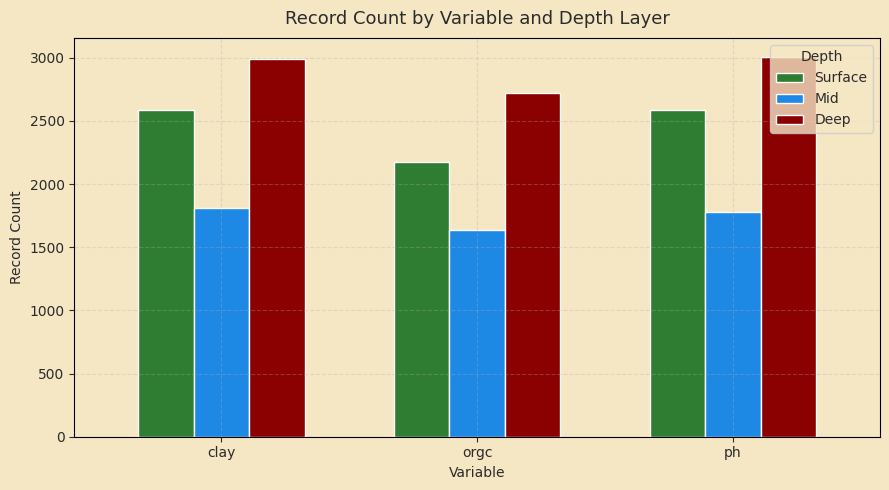

In [8]:
DEPTH_ORDER = ["Surface", "Mid", "Deep"]
depth_counts = (
    soil_long
    .groupby(["variable", "depth_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=DEPTH_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [PALETTE["neutral"], PALETTE["alkaline"], PALETTE["acid"]]
depth_counts.plot(kind="bar", ax=ax, color=bar_colors, edgecolor="white", width=0.65)
ax.set_title("Record Count by Variable and Depth Layer",
             color=PALETTE["charcoal"], fontsize=13, pad=10)
ax.set_xlabel("Variable", color=PALETTE["charcoal"])
ax.set_ylabel("Record Count", color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(title="Depth", labelcolor=PALETTE["charcoal"])
plt.xticks(rotation=0)
clean_plot()
plt.show()

## 1.6 Spatial coverage map

Where are the samples? Colour by country to reveal geographic density patterns before any analysis begins.

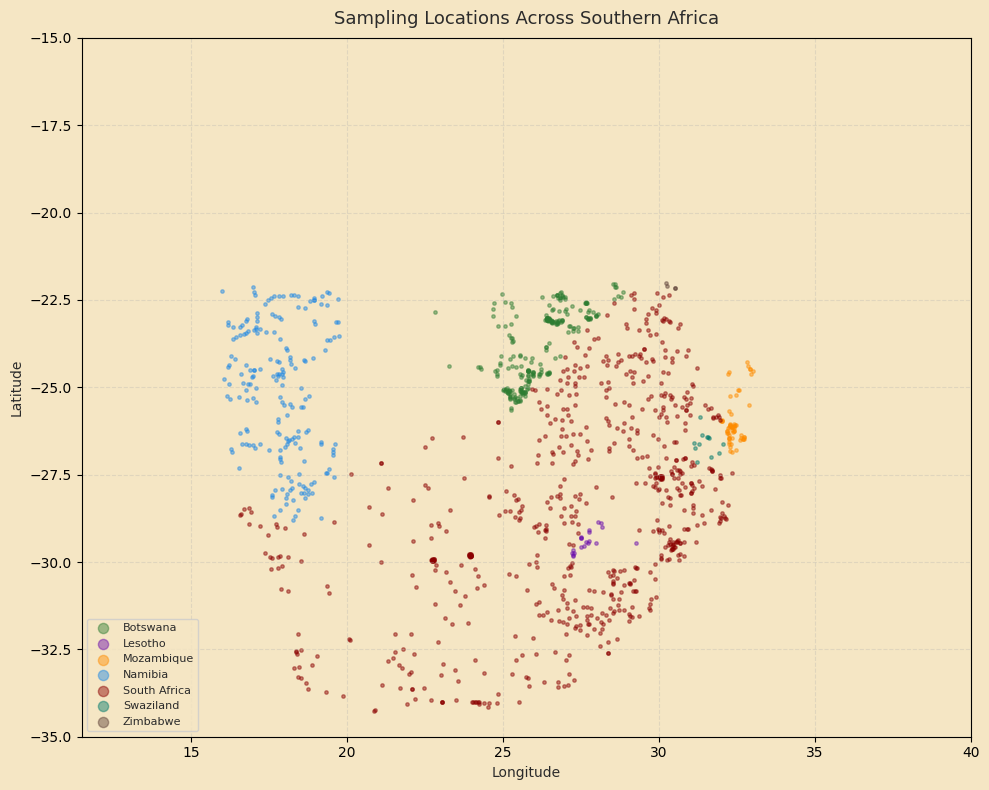

In [9]:
unique_locs = soil_long.drop_duplicates(subset=["longitude", "latitude", "country_name"])

fig, ax = plt.subplots(figsize=(10, 8))
for country, grp in unique_locs.groupby("country_name"):
    ax.scatter(
        grp["longitude"], grp["latitude"],
        s=6, alpha=0.45,
        color=COUNTRY_COLORS.get(country, "#888888"),
        label=country
    )
ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
ax.set_title("Sampling Locations Across Southern Africa",
             color=PALETTE["charcoal"], fontsize=13, pad=10)
ax.set_xlabel("Longitude", color=PALETTE["charcoal"])
ax.set_ylabel("Latitude",  color=PALETTE["charcoal"])
ax.legend(loc="lower left", fontsize=8, markerscale=3,
          facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()

## 1.7 Value distributions — Surface layer

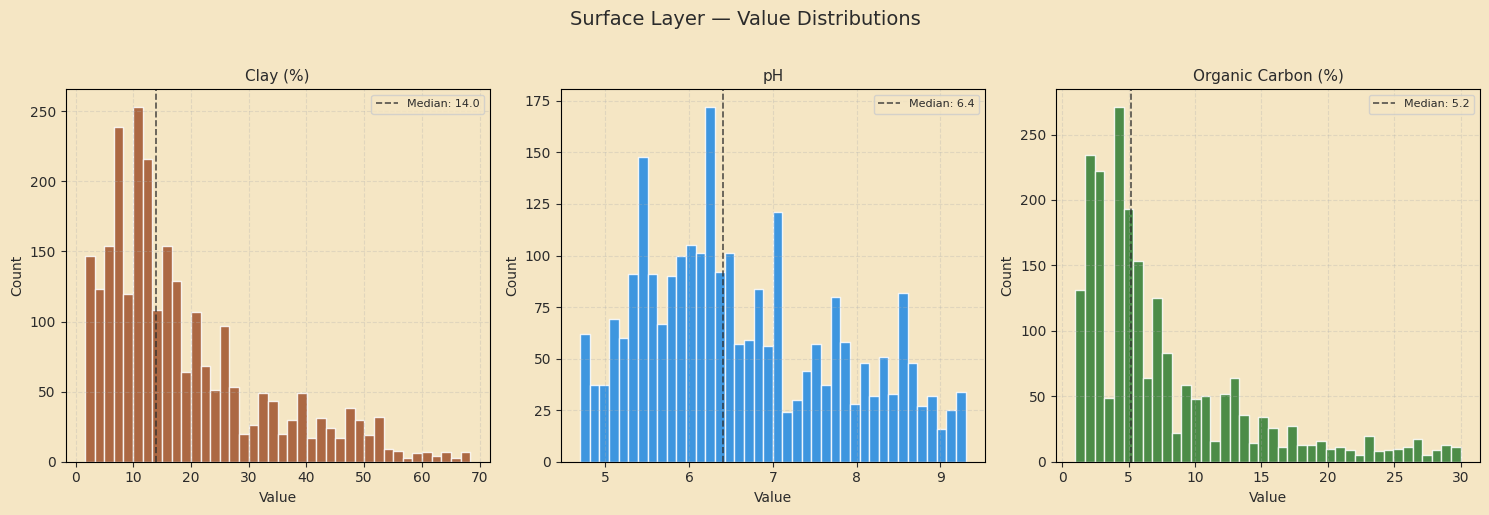

In [10]:
surface_all = soil_long[soil_long["depth_category"] == "Surface"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(PALETTE["sand"])

for ax, (var, label) in zip(axes, VAR_LABELS.items()):
    data = surface_all[surface_all["variable"] == var]["value_avg"].dropna()
    ax.hist(data, bins=40, color=VAR_COLORS[var], edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color=PALETTE["charcoal"], linestyle="--",
               linewidth=1.2, alpha=0.8, label=f"Median: {data.median():.1f}")
    ax.set_title(label, color=PALETTE["charcoal"], fontsize=11)
    ax.set_xlabel("Value", color=PALETTE["charcoal"])
    ax.set_ylabel("Count",  color=PALETTE["charcoal"])
    ax.set_facecolor(PALETTE["sand"])
    ax.tick_params(colors=PALETTE["charcoal"])
    ax.legend(fontsize=8, facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
    ax.grid(True, linestyle="--", alpha=0.3)

fig.patch.set_facecolor(PALETTE["sand"])
plt.suptitle("Surface Layer — Value Distributions",
             color=PALETTE["charcoal"], fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 1.8 Surface record density by decade

Which decades have enough coverage for temporal analysis? This chart guides the decade selection in Notebooks 2 and 3.

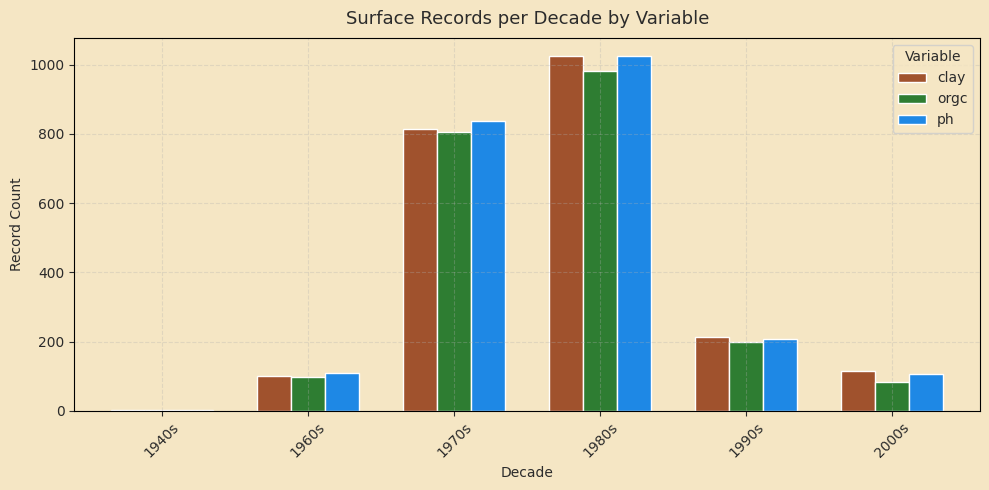


Note: 1940s has only 2 records — excluded from spatial modelling.
Primary modelling decades: 1960s · 1970s · 1980s · 1990s · 2000s


In [11]:
DECADE_ORDER = ["1940s","1950s","1960s","1970s","1980s","1990s","2000s"]

surface_dated = surface_all[surface_all["decade"].notna()]
decade_counts = (
    surface_dated
    .groupby(["decade", "variable"])
    .size()
    .unstack(fill_value=0)
    .reindex([d for d in DECADE_ORDER if d in surface_dated["decade"].unique()])
)

fig, ax = plt.subplots(figsize=(10, 5))
decade_counts.plot(
    kind="bar", ax=ax,
    color=[VAR_COLORS[v] for v in decade_counts.columns],
    edgecolor="white", width=0.7
)
ax.set_title("Surface Records per Decade by Variable",
             color=PALETTE["charcoal"], fontsize=13, pad=10)
ax.set_xlabel("Decade",        color=PALETTE["charcoal"])
ax.set_ylabel("Record Count",  color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(title="Variable", labelcolor=PALETTE["charcoal"])
plt.xticks(rotation=45)
clean_plot()
plt.show()

print("\nNote: 1940s has only 2 records — excluded from spatial modelling.")
print("Primary modelling decades: 1960s · 1970s · 1980s · 1990s · 2000s")

## 1.9 Save outputs

In [12]:
soil_long.to_csv("soil_long.csv", index=False)
clay[KEEP_COLS].to_csv("clay_ready.csv", index=False)
ph[KEEP_COLS].to_csv("ph_ready.csv", index=False)
orgc[KEEP_COLS].to_csv("orgc_ready.csv", index=False)

print("Saved:")
print("  soil_long.csv   ← primary input for Notebooks 2 & 3")
print("  clay_ready.csv")
print("  ph_ready.csv")
print("  orgc_ready.csv")

Saved:
  soil_long.csv   ← primary input for Notebooks 2 & 3
  clay_ready.csv
  ph_ready.csv
  orgc_ready.csv
